# Cancelamento de cartões de crédito: quem vai sair, por quê e quanto vale agir

**Autor:** [Rodrigo Aparecido Campos de Oliveira](https://www.linkedin.com/in/rodrigo-aparecido-397a0b154) · Python · pandas · scipy · scikit-learn · matplotlib

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RodrigoAp727/previsao-cancelamento-cartoes/blob/main/notebooks/analise_cancelamento_cartoes.ipynb)

## O problema de negócio

A diretoria de uma emissora de cartões percebeu que os cancelamentos estão aumentando e causando prejuízo. Este estudo responde três perguntas:

1. **Quem cancela?** Quais comportamentos separam quem cancela de quem fica.
2. **Dá para prever?** Um modelo que atribui a cada cliente uma probabilidade de cancelar, a tempo de agir.
3. **Vale a pena agir?** Quantos clientes a área de retenção deve contatar para ter o maior retorno financeiro.

**Base:** 10.127 clientes (ativos e cancelados) com dados cadastrais, de relacionamento e de uso do cartão nos últimos 12 meses. Fonte: [Kaggle, Credit Card Customers](https://www.kaggle.com/sakshigoyal7/credit-card-customers), versão traduzida.

> ### Resumo executivo
>
> - **16,1% dos clientes cancelaram** (1.627 de 10.127).
> - **O cancelamento é anunciado pelo comportamento, não pelo perfil.** Quem faz até 60 transações por ano cancela entre 29% e 40%; acima disso, 7% ou menos. Quando o uso cai forte de um trimestre para outro (Q4/Q1 abaixo de 0,40), a taxa chega a **60%**. Sexo, renda, escolaridade e estado civil praticamente não influenciam.
> - **Atrito no atendimento é um alarme:** a taxa sobe de 2% (nenhum contato com o banco) para 34% (5 contatos). Os 54 clientes com 6 contatos cancelaram todos.
> - **O modelo de gradient boosting identifica 89% dos cancelamentos com 92% de precisão** em dados que nunca viu (ROC-AUC 0,993; PR-AUC 0,968, contra 0,760 da regressão logística).
> - **Retorno:** priorizando pelo modelo, contatar **19% da base** alcança **96% dos cancelamentos** e gera lucro estimado de **\$32 mil a cada 2 mil clientes**, 3,2 vezes o resultado de uma regra simples. Contatar todos daria prejuízo.
> - **Qualidade de dados:** um erro de escala em 9% dos registros de duas variáveis foi identificado e corrigido antes da análise.

## 1. Configuração

In [1]:
# No Google Colab, baixa o repositório para ter acesso aos dados e aos módulos de src/
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/RodrigoAp727/previsao-cancelamento-cartoes.git
    %cd previsao-cancelamento-cartoes/notebooks

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # permite importar src/ a partir de notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, confusion_matrix, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split

from src import dados, graficos as g, modelagem as m

g.aplicar_estilo()
pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 30)

## 2. Qualidade dos dados

Antes de qualquer análise, a base precisa ser confiável. A limpeza fica em `src/dados.py`, para que o mesmo tratamento seja usado no notebook, no modelo e em produção.

In [3]:
bruto = dados.carregar_bruto()
df, log = dados.tratar(bruto)
dados.CAMINHO_TRATADO.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(dados.CAMINHO_TRATADO, index=False)

print(f"Linhas: {log['linhas_brutas']:,} | IDs duplicados: {log['ids_duplicados']}")
print(f"Nulos encontrados: {log['nulos']}")
print(f"Razões Q4/Q1 com erro de escala corrigidas: {log['razoes_corrigidas']}")
df.head()

Linhas: 10,127 | IDs duplicados: 0
Nulos encontrados: {'categoria_cartao': 1}
Razões Q4/Q1 com erro de escala corrigidas: {'var_valor_q4_q1': 905, 'var_qtd_q4_q1': 546}


,id_cliente,categoria,idade,sexo,dependentes,escolaridade,estado_civil,faixa_salarial,categoria_cartao,meses_cliente,qtd_produtos,meses_inativo_12m,contatos_12m,limite,saldo_rotativo,limite_disponivel,var_valor_q4_q1,valor_transacoes_12m,qtd_transacoes_12m,var_qtd_q4_q1,taxa_utilizacao,churn,ticket_medio
0,768805383,Cliente,45,M,3,Ensino Médio,Casado,$60K - $80K,Blue,39,5,1,3,"12,691.000",777,"11,914.000",1.335,1144,42,1.625,0.061,0,27.238
1,818770008,Cliente,49,F,5,Ensino Superior,Solteiro,Less than $40K,Blue,44,6,1,2,"8,256.000",864,"7,392.000",1.541,1291,33,3.714,0.105,0,39.121
2,713982108,Cliente,51,M,3,Ensino Superior,Casado,$80K - $120K,Blue,36,4,1,0,"3,418.000",0,"3,418.000",2.594,1887,20,2.333,0.000,0,94.350
3,769911858,Cliente,40,F,4,Ensino Médio,Não informado,Less than $40K,Blue,34,3,4,1,"3,313.000",2517,796.000,1.405,1171,20,2.333,0.760,0,58.550
4,709106358,Cliente,40,M,3,Sem ensino formal,Casado,$60K - $80K,Blue,21,5,1,0,"4,716.000",0,"4,716.000",2.175,816,28,2.500,0.000,0,29.143


### Um erro que a análise original não detectava

As colunas `var_valor_q4_q1` e `var_qtd_q4_q1` são **razões** (movimento do 4º trimestre dividido pelo do 1º), com valores típicos entre 0,5 e 1,0. Em parte das linhas o separador decimal se perdeu na exportação: `1,335` virou `1335`. Sem correção, a média da coluna fica mais de 100 vezes maior do que deveria, e qualquer gráfico ou modelo com essa variável sai distorcido.

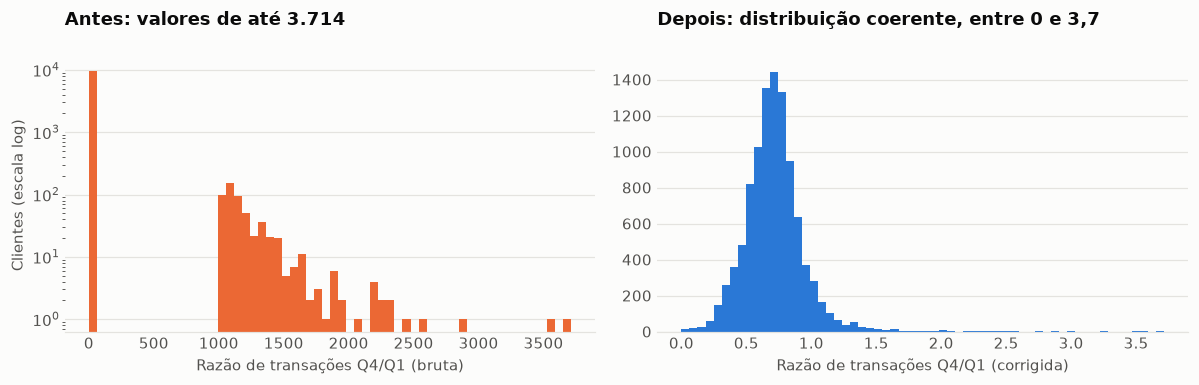

Média antes: 66.6 | Média depois: 0.712


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
bruto_razao = bruto["Mudança Qtde Transações_Q4_Q1"]
axes[0].hist(bruto_razao, bins=60, color=g.LARANJA)
axes[0].set_yscale("log")
axes[0].set_title("Antes: valores de até 3.714")
axes[0].set_xlabel("Razão de transações Q4/Q1 (bruta)")
axes[0].set_ylabel("Clientes (escala log)")
axes[1].hist(df["var_qtd_q4_q1"], bins=60, color=g.AZUL)
axes[1].set_title("Depois: distribuição coerente, entre 0 e 3,7")
axes[1].set_xlabel("Razão de transações Q4/Q1 (corrigida)")
fig.tight_layout()
g.salvar(fig, "00_correcao_escala")
plt.show()

print("Média antes: {:.1f} | Média depois: {:.3f}".format(bruto_razao.mean(), df["var_qtd_q4_q1"].mean()))

**Outras decisões de tratamento:**

- **Nulo em `categoria_cartao`:** era uma única linha. Em vez de apagar o cliente (`dropna`), ele recebe a categoria "Não informado".
- **Redundância:** `limite = saldo_rotativo + limite_disponivel` vale em 100% das linhas (verificado em `dados.validar`). `limite_disponivel` fica fora do modelo para não duplicar informação.
- **Nova variável:** `ticket_medio = valor_transacoes_12m / qtd_transacoes_12m`.

## 3. Tamanho do problema

In [5]:
taxa_base = df["churn"].mean()
contagem = df["categoria"].value_counts()
print(f"{contagem['Cancelado']:,} de {len(df):,} clientes cancelaram: taxa de {taxa_base:.1%}")

1,627 de 10,127 clientes cancelaram: taxa de 16.1%


Cerca de **1 em cada 6 clientes** cancelou. É uma base desbalanceada: um modelo que dissesse "ninguém cancela" acertaria 84% das vezes e não teria utilidade nenhuma. Por isso, mais adiante, a avaliação usa ROC-AUC, PR-AUC e *recall*, e não acurácia.

## 4. O que separa quem cancela de quem fica

Em vez de gerar um histograma para cada coluna, o primeiro passo é **medir** a força da relação de cada variável com o cancelamento, e só depois aprofundar nas que importam:

- **Variáveis numéricas:** teste de Mann-Whitney, com o tamanho de efeito medido pela correlação rank-biserial (|r|, de 0 a 1).
- **Variáveis categóricas:** teste qui-quadrado, com o tamanho de efeito medido pelo V de Cramér (de 0 a 1).

In [6]:
numericas = [c for c in df.select_dtypes("number").columns if c not in ("id_cliente", "churn")]
linhas = []
for col in numericas:
    cancelou, ficou = df.loc[df.churn == 1, col], df.loc[df.churn == 0, col]
    u, p = stats.mannwhitneyu(cancelou, ficou)
    efeito = 1 - 2 * u / (len(cancelou) * len(ficou))  # rank-biserial: >0 = maior entre quem fica
    linhas.append({"variavel": col, "tipo": "numérica", "efeito": abs(efeito),
                   "direcao": "maior em quem fica" if efeito > 0 else "maior em quem cancela", "p_valor": p})
for col in dados.COLUNAS_CATEGORICAS:
    tabela = pd.crosstab(df[col], df["churn"])
    qui2, p, _, _ = stats.chi2_contingency(tabela)
    v_cramer = np.sqrt(qui2 / (len(df) * (min(tabela.shape) - 1)))
    linhas.append({"variavel": col, "tipo": "categórica", "efeito": v_cramer, "direcao": "-", "p_valor": p})

efeitos = pd.DataFrame(linhas).sort_values("efeito", ascending=False).reset_index(drop=True)
efeitos["significativa (p<0,01)"] = efeitos["p_valor"] < 0.01
efeitos

,variavel,tipo,efeito,direcao,p_valor,"significativa (p<0,01)"
0,qtd_transacoes_12m,numérica,0.591,maior em quem fica,0.000,True
1,var_qtd_q4_q1,numérica,0.491,maior em quem fica,0.000,True
2,saldo_rotativo,numérica,0.375,maior em quem fica,0.000,True
3,taxa_utilizacao,numérica,0.375,maior em quem fica,0.000,True
4,valor_transacoes_12m,numérica,0.352,maior em quem fica,0.000,True
5,contatos_12m,numérica,0.286,maior em quem cancela,0.000,True
6,meses_inativo_12m,numérica,0.256,maior em quem cancela,0.000,True
7,qtd_produtos,numérica,0.231,maior em quem fica,0.000,True
8,var_valor_q4_q1,numérica,0.160,maior em quem fica,0.000,True
9,limite,numérica,0.080,maior em quem fica,0.000,True


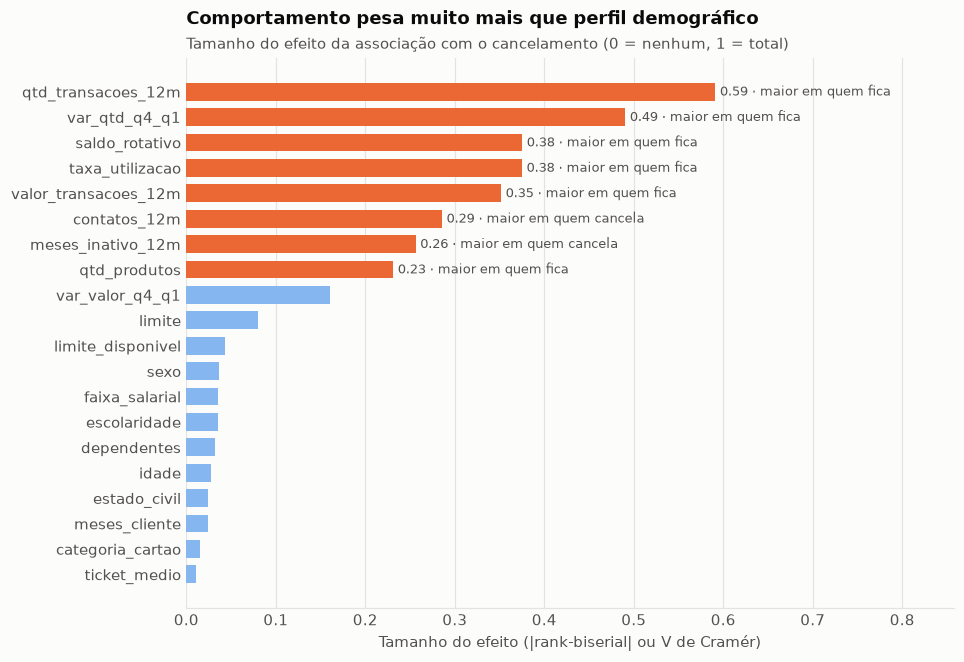

In [7]:
top = efeitos.sort_values("efeito")
fig, ax = plt.subplots(figsize=(9, 6.5))
cores = [g.LARANJA if e >= 0.2 else g.AZUL_CLARO for e in top["efeito"]]
ax.barh(top["variavel"], top["efeito"], color=cores, height=0.7)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
for y, (e, d) in enumerate(zip(top["efeito"], top["direcao"])):
    if e >= 0.2:
        ax.text(e + 0.005, y, f"{e:.2f} · {d}", va="center", fontsize=8.5, color=g.TEXTO_SECUNDARIO)
ax.set_title("Comportamento pesa muito mais que perfil demográfico")
g.subtitulo(ax, "Tamanho do efeito da associação com o cancelamento (0 = nenhum, 1 = total)")
ax.set_xlabel("Tamanho do efeito (|rank-biserial| ou V de Cramér)")
ax.set_xlim(0, top["efeito"].max() * 1.45)
g.salvar(fig, "01_ranking_variaveis")
plt.show()

**Leitura:** as variáveis mais fortes são todas de **uso do cartão e relacionamento** (quantidade de transações, variação entre trimestres, saldo rotativo, produtos contratados, contatos com o banco). Sexo, escolaridade, faixa salarial e estado civil têm efeito próximo de zero: **não adianta segmentar a retenção por perfil demográfico**.

A seguir, cada um dos grandes sinais em detalhe.

In [8]:
def taxa_por_faixa(coluna, bins=None, rotulos=None):
    serie = pd.cut(df[coluna], bins=bins, labels=rotulos) if bins is not None else df[coluna]
    return df.groupby(serie, observed=True)["churn"].agg(taxa="mean", clientes="size")


def barras_taxa(ax, resumo, titulo, subtitulo_txt, xlabel, destaque_acima=None):
    destaque_acima = taxa_base * 1.5 if destaque_acima is None else destaque_acima
    cores = [g.LARANJA if t > destaque_acima else g.AZUL for t in resumo["taxa"]]
    x = resumo.index.astype(str)
    ax.bar(x, resumo["taxa"], color=cores, width=0.7)
    for xi, (t, n) in enumerate(zip(resumo["taxa"], resumo["clientes"])):
        ax.text(xi, t + 0.012, f"{t:.0%}", ha="center", fontsize=9, color=g.TEXTO)
    g.linha_media(ax, taxa_base)
    g.eixo_percentual(ax)
    ax.set_ylim(0, resumo["taxa"].max() * 1.15)
    ax.set_title(titulo)
    g.subtitulo(ax, f"{subtitulo_txt} · tracejado = média {taxa_base:.0%}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Taxa de cancelamento")

### 4.1 Sinal nº 1: o cliente para de usar o cartão antes de cancelar

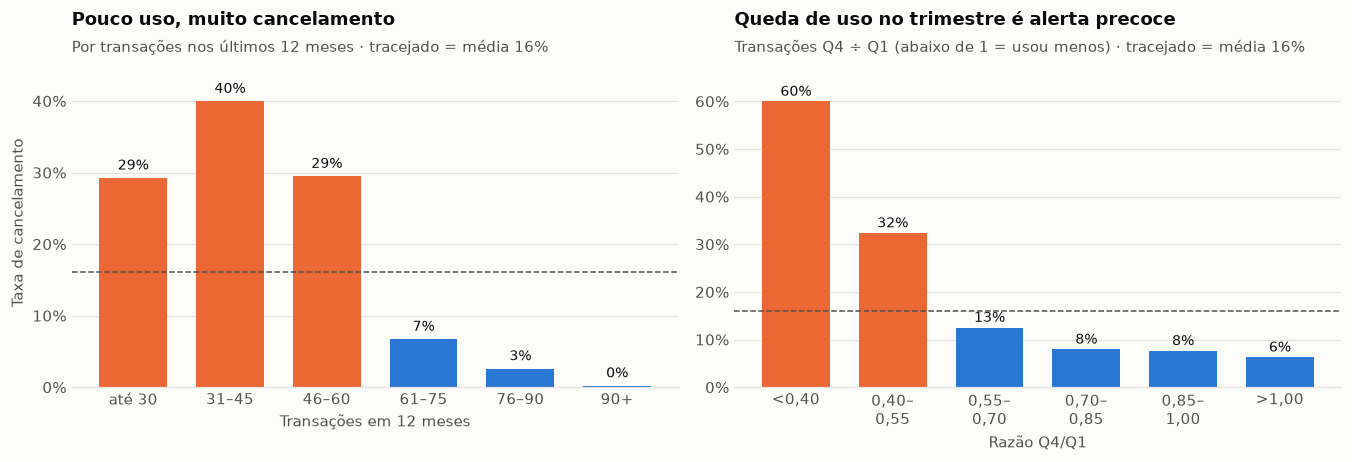

,taxa,clientes
qtd_transacoes_12m,,
até 30,29.2%,698
31–45,39.9%,1913
46–60,29.5%,1436
61–75,6.7%,2588
76–90,2.6%,2376
90+,0.2%,1116


,taxa,clientes
var_qtd_q4_q1,,
"<0,40",60.0%,692
"0,40– 0,55",32.4%,1403
"0,55– 0,70",12.5%,2963
"0,70– 0,85",7.9%,3012
"0,85– 1,00",7.6%,1389
">1,00",6.3%,668


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
r1 = taxa_por_faixa("qtd_transacoes_12m", [0, 30, 45, 60, 75, 90, 200],
                    ["até 30", "31–45", "46–60", "61–75", "76–90", "90+"])
barras_taxa(axes[0], r1, "Pouco uso, muito cancelamento", "Por transações nos últimos 12 meses",
            "Transações em 12 meses")
r2 = taxa_por_faixa("var_qtd_q4_q1", [-0.01, 0.4, 0.55, 0.7, 0.85, 1.0, 4],
                    ["<0,40", "0,40–\n0,55", "0,55–\n0,70", "0,70–\n0,85", "0,85–\n1,00", ">1,00"])
barras_taxa(axes[1], r2, "Queda de uso no trimestre é alerta precoce",
            "Transações Q4 ÷ Q1 (abaixo de 1 = usou menos)", "Razão Q4/Q1")
axes[1].set_ylabel("")
fig.tight_layout()
g.salvar(fig, "02_uso_do_cartao")
plt.show()
display(r1.style.format({"taxa": "{:.1%}"}), r2.style.format({"taxa": "{:.1%}"}))

**Leitura:** a relação funciona quase como um degrau. Até 60 transações no ano, a taxa de cancelamento fica entre 29% e 40%. Acima de 60, cai para 7% ou menos, e é praticamente zero acima de 90.

A variação trimestral é ainda mais útil porque funciona como **alerta precoce**: clientes cujo número de transações no 4º trimestre caiu para menos de 40% do 1º cancelam em **60%** dos casos. Monitorar essa queda todo mês permite agir antes de o cliente decidir sair.

### 4.2 Sinal nº 2: relacionamento fraco e atrito no atendimento

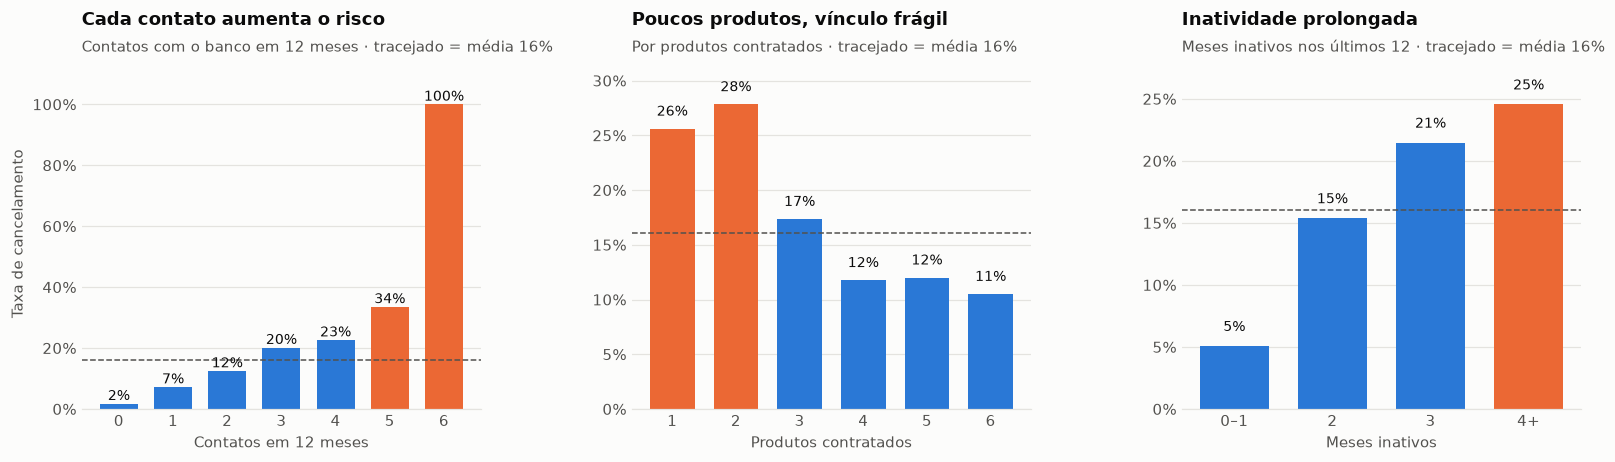

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
barras_taxa(axes[0], taxa_por_faixa("contatos_12m"), "Cada contato aumenta o risco",
            "Contatos com o banco em 12 meses", "Contatos em 12 meses")
barras_taxa(axes[1], taxa_por_faixa("qtd_produtos"), "Poucos produtos, vínculo frágil",
            "Por produtos contratados", "Produtos contratados")
inat = taxa_por_faixa("meses_inativo_12m", [-1, 1, 2, 3, 12], ["0–1", "2", "3", "4+"])
barras_taxa(axes[2], inat, "Inatividade prolongada", "Meses inativos nos últimos 12",
            "Meses inativos")
for ax in axes[1:]:
    ax.set_ylabel("")
fig.tight_layout()
g.salvar(fig, "03_relacionamento")
plt.show()

**Leitura:**

- **Contatos com o banco:** o risco sobe a cada contato, de 2% (nenhum) a 34% (5). Os 54 clientes com 6 contatos cancelaram todos. A hipótese mais provável é que sejam reclamações não resolvidas. É também o momento mais barato para intervir, porque o cliente já está falando com o banco.
- **Produtos contratados:** com 1 ou 2 produtos, a taxa é de 26% a 28%; com 4 ou mais, cai para 11% a 12%. Vender mais produtos (*cross-sell*) também é uma estratégia de retenção.
- **Inatividade:** a partir de 3 meses sem uso, a taxa passa de 21%. (Os 29 clientes com zero meses inativos foram agrupados com "1" por serem poucos demais para uma leitura isolada.)

### 4.3 Sinal nº 3: quem não usa o rotativo tem pouco vínculo financeiro

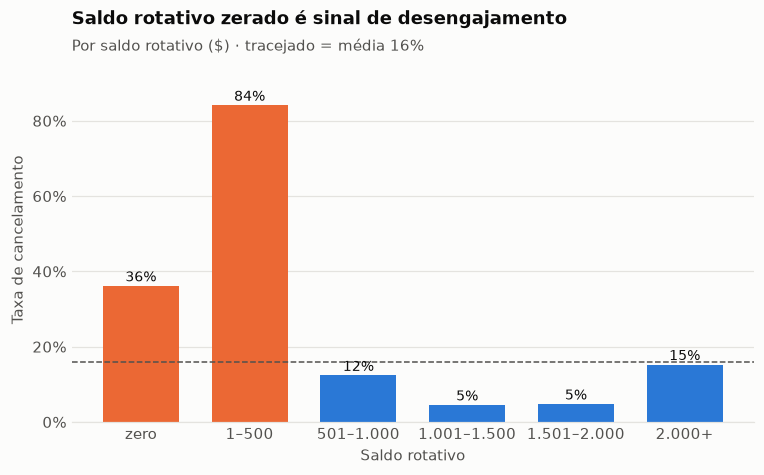

,taxa,clientes
saldo_rotativo,,
zero,36.2%,2470
1–500,84.1%,126
501–1.000,12.4%,1317
1.001–1.500,4.5%,2258
1.501–2.000,4.8%,2291
2.000+,15.3%,1665


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.3))
rot = taxa_por_faixa("saldo_rotativo", [-1, 0, 500, 1000, 1500, 2000, 2600],
                     ["zero", "1–500", "501–1.000", "1.001–1.500", "1.501–2.000", "2.000+"])
barras_taxa(ax, rot, "Saldo rotativo zerado é sinal de desengajamento", "Por saldo rotativo ($)",
            "Saldo rotativo")
g.salvar(fig, "04_saldo_rotativo")
plt.show()
display(rot.style.format({"taxa": "{:.1%}"}))

**Leitura:** clientes **sem saldo rotativo cancelam 36%**, mais que o dobro da média, e são 24% da base (2.470 clientes). Quem mantém entre \$1.000 e \$2.000 de rotativo cancela menos de 5%. O saldo rotativo indica se o cartão é o principal meio de pagamento do cliente.

Duas faixas fogem do padrão e merecem investigação com a área de crédito: de \$1 a \$500 (84% de cancelamento, mas só 126 clientes, provavelmente saldo residual de quem já está encerrando a conta) e acima de \$2.000 (15%, possivelmente clientes no limite do crédito).

### 4.4 Segmentos de risco: uma regra que qualquer área consegue usar

Antes do modelo, uma pergunta prática: dá para montar uma regra simples, que caiba numa consulta SQL, e já concentrar os cancelamentos? Combinando os sinais acima:

Sinais avaliados:
- Poucas transações (≤ 60)
- Queda de uso no trimestre (Q4/Q1 < 0,6)
- 3+ contatos com o banco
- Até 2 produtos
- Rotativo zerado


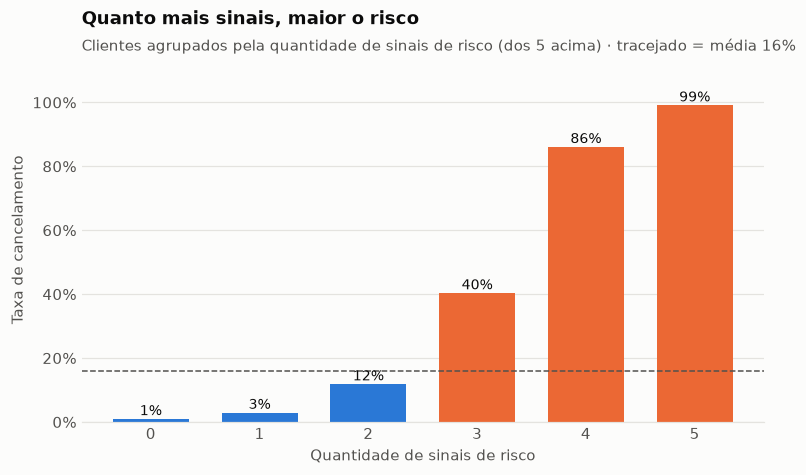

,taxa,clientes,cancelados,pct_base,pct_cancelados
qtd_sinais_risco,,,,,
0,1.0%,1573,15,15.5%,0.9%
1,2.9%,3477,101,34.3%,6.2%
2,11.8%,3008,356,29.7%,21.9%
3,40.3%,1399,564,13.8%,34.7%
4,86.1%,560,482,5.5%,29.6%
5,99.1%,110,109,1.1%,6.7%


In [12]:
sinais = m.sinais_de_risco(df)  # a mesma regra usada em produção, definida em src/modelagem.py
print("Sinais avaliados:", *sinais.columns, sep="\n- ")
df["qtd_sinais_risco"] = sinais.sum(axis=1)

segmentos = df.groupby("qtd_sinais_risco")["churn"].agg(taxa="mean", clientes="size", cancelados="sum")
segmentos["pct_base"] = segmentos["clientes"] / len(df)
segmentos["pct_cancelados"] = segmentos["cancelados"] / df["churn"].sum()

fig, ax = plt.subplots(figsize=(8, 4.3))
barras_taxa(ax, segmentos, "Quanto mais sinais, maior o risco",
            "Clientes agrupados pela quantidade de sinais de risco (dos 5 acima)", "Quantidade de sinais de risco")
g.salvar(fig, "05_sinais_de_risco")
plt.show()
segmentos.style.format({"taxa": "{:.1%}", "pct_base": "{:.1%}", "pct_cancelados": "{:.1%}"})

**Leitura:** mesmo sem modelo, contar os 5 sinais já separa bem os grupos:

- Clientes com **3 ou mais sinais** são **20% da base** e concentram **71% dos cancelamentos**.
- Com 4 ou 5 sinais, a taxa vai de 86% a 99%. Com 0 ou 1 sinal, fica abaixo de 3%.

É uma regra que pode ser implementada **hoje**, em SQL, enquanto o modelo não entra em produção.

## 5. Modelo preditivo de cancelamento

A regra funciona, mas trata todos os clientes de um grupo do mesmo jeito. Um modelo atribui a **cada cliente** uma probabilidade de cancelar, o que permite ordenar a fila da área de retenção.

**Protocolo de avaliação:**
- 20% da base fica separada como **teste**. Ela só é usada no final, uma única vez.
- Nos 80% de treino, os modelos são comparados por **validação cruzada estratificada de 5 partes**.
- **Regressão logística** serve de referência (*baseline*). O **gradient boosting** é o candidato, porque a análise exploratória mostrou relações não lineares: por exemplo, a taxa de cancelamento sobe e depois despenca conforme o valor transacionado.

In [13]:
X, y = m.separar_x_y(df.drop(columns="qtd_sinais_risco"))
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=m.SEMENTE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=m.SEMENTE)
metricas = {"ROC-AUC": "roc_auc", "PR-AUC": "average_precision", "Recall": "recall", "Precisão": "precision"}
candidatos = {"Regressão logística (baseline)": m.modelo_baseline(X), "Gradient boosting": m.modelo_boosting(X)}

resultados = {}
for nome, modelo in candidatos.items():
    r = cross_validate(modelo, X_treino, y_treino, cv=cv, scoring=metricas)
    resultados[nome] = {k: f"{r['test_' + k].mean():.3f} ± {r['test_' + k].std():.3f}" for k in metricas}
pd.DataFrame(resultados).T

,ROC-AUC,PR-AUC,Recall,Precisão
Regressão logística (baseline),0.934 ± 0.006,0.771 ± 0.019,0.861 ± 0.017,0.549 ± 0.014
Gradient boosting,0.994 ± 0.001,0.972 ± 0.007,0.908 ± 0.014,0.914 ± 0.016


**Leitura:** o gradient boosting supera a regressão logística em todas as métricas, com desvio pequeno entre as 5 partes (resultado estável). O maior ganho é na **precisão (0,55 → 0,91)**. A regressão logística encontra os cancelamentos, mas gera quase um alarme falso para cada acerto, o que desperdiçaria orçamento de retenção com clientes que não iam sair.

### 5.1 Escolha do ponto de corte

O modelo devolve uma probabilidade. O ponto de corte ("a partir de quanto consideramos o cliente em risco?") é uma **decisão de negócio**, não um padrão fixo em 0,5. Ele é escolhido com predições *out-of-fold* do treino, maximizando o F1 (equilíbrio entre não deixar cancelamentos passarem e não sobrecarregar a equipe), e só depois aplicado ao teste.

In [14]:
modelo = m.modelo_boosting(X)
proba_oof = cross_val_predict(modelo, X_treino, y_treino, cv=cv, method="predict_proba")[:, 1]
precisao, recall, cortes = precision_recall_curve(y_treino, proba_oof)
f1 = 2 * precisao * recall / (precisao + recall + 1e-12)
corte = cortes[np.argmax(f1[:-1])]
print(f"Ponto de corte escolhido: {corte:.2f}")

modelo.fit(X_treino, y_treino)
proba_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= corte).astype(int)

resultado_teste = {
    "ROC-AUC": roc_auc_score(y_teste, proba_teste),
    "PR-AUC": average_precision_score(y_teste, proba_teste),
    "Recall": recall_score(y_teste, pred_teste),
    "Precisão": precision_score(y_teste, pred_teste),
}
pd.Series(resultado_teste, name="Base de teste (nunca vista)").to_frame()

Ponto de corte escolhido: 0.54


,Base de teste (nunca vista)
ROC-AUC,0.993
PR-AUC,0.968
Recall,0.895
Precisão,0.921


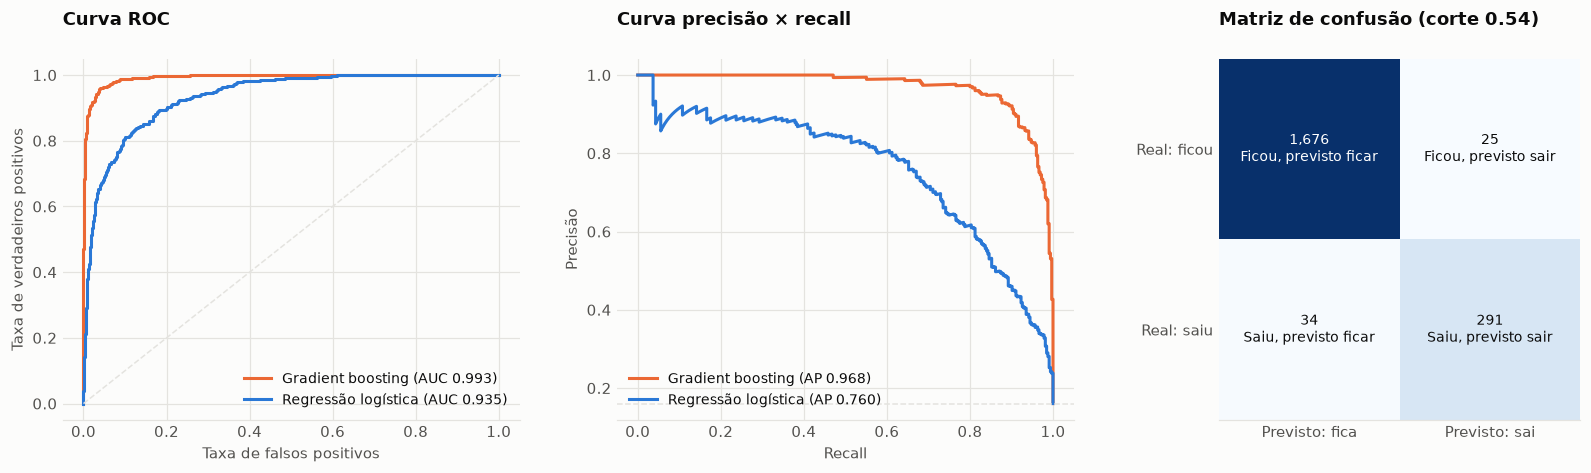

In [15]:
baseline = m.modelo_baseline(X).fit(X_treino, y_treino)
proba_baseline = baseline.predict_proba(X_teste)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for proba, nome, cor in [(proba_teste, "Gradient boosting", g.LARANJA), (proba_baseline, "Regressão logística", g.AZUL)]:
    fpr, tpr, _ = roc_curve(y_teste, proba)
    axes[0].plot(fpr, tpr, color=cor, label=f"{nome} (AUC {roc_auc_score(y_teste, proba):.3f})")
    p, r, _ = precision_recall_curve(y_teste, proba)
    axes[1].plot(r, p, color=cor, label=f"{nome} (AP {average_precision_score(y_teste, proba):.3f})")
axes[0].plot([0, 1], [0, 1], color=g.GRADE, linestyle="--", linewidth=1)
axes[0].set(title="Curva ROC", xlabel="Taxa de falsos positivos", ylabel="Taxa de verdadeiros positivos")
axes[1].axhline(y_teste.mean(), color=g.GRADE, linestyle="--", linewidth=1)
axes[1].set(title="Curva precisão × recall", xlabel="Recall", ylabel="Precisão")
for ax in axes[:2]:
    ax.legend(loc="lower left" if ax is axes[1] else "lower right", fontsize=9)
    ax.grid(axis="x", visible=True)

matriz = confusion_matrix(y_teste, pred_teste)
axes[2].imshow(matriz, cmap="Blues")
axes[2].grid(False)
rotulos = [["Ficou, previsto ficar", "Ficou, previsto sair"], ["Saiu, previsto ficar", "Saiu, previsto sair"]]
for i in range(2):
    for j in range(2):
        cor_texto = "white" if matriz[i, j] > matriz.max() / 2 else g.TEXTO
        axes[2].text(j, i, f"{matriz[i, j]:,}\n{rotulos[i][j]}", ha="center", va="center", color=cor_texto, fontsize=9)
axes[2].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Previsto: fica", "Previsto: sai"],
            yticklabels=["Real: ficou", "Real: saiu"], title=f"Matriz de confusão (corte {corte:.2f})")
fig.tight_layout()
g.salvar(fig, "06_desempenho_modelo")
plt.show()

**Leitura:** na base de teste, que o modelo nunca viu, o desempenho confirma a validação cruzada, sem sinal de *overfitting*:

- De **325** clientes que cancelaram, **291** foram identificados (recall de 89,5%).
- Dos **316** alertas emitidos, **291** estavam certos (precisão de 92%). Só 25 dos 1.701 clientes que ficaram receberam alerta indevido.

### 5.2 O que o modelo aprendeu

A **importância por permutação** mede o quanto o desempenho (PR-AUC) cai quando os valores de uma variável são embaralhados na base de teste. Quanto maior a queda, mais o modelo depende dela.

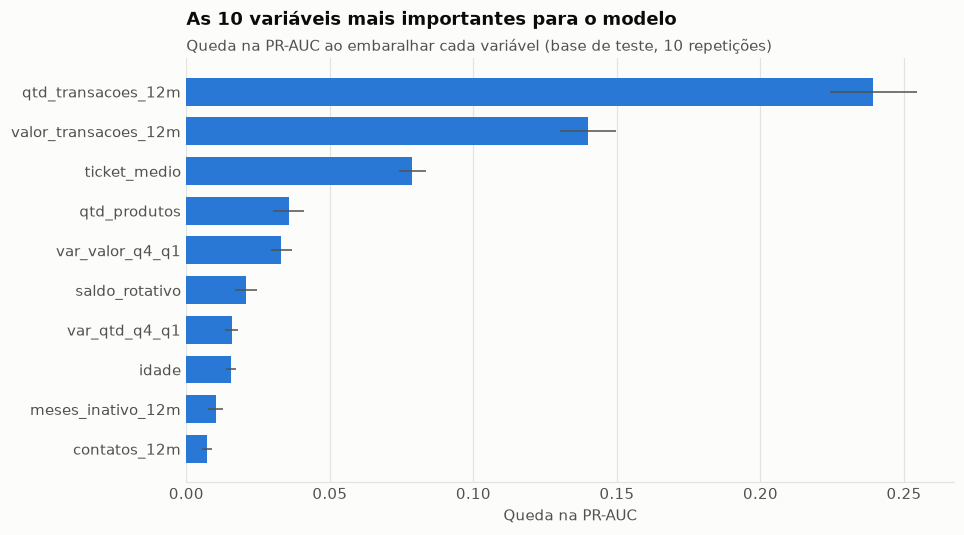

In [16]:
imp = permutation_importance(modelo, X_teste, y_teste, scoring="average_precision",
                             n_repeats=10, random_state=m.SEMENTE, n_jobs=-1)
importancia = (pd.DataFrame({"variavel": X_teste.columns, "queda_pr_auc": imp.importances_mean,
                             "desvio": imp.importances_std})
               .sort_values("queda_pr_auc", ascending=True).tail(10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importancia["variavel"], importancia["queda_pr_auc"], xerr=importancia["desvio"],
        color=g.AZUL, height=0.7, error_kw={"ecolor": g.TEXTO_SECUNDARIO, "lw": 1})
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("As 10 variáveis mais importantes para o modelo")
g.subtitulo(ax, "Queda na PR-AUC ao embaralhar cada variável (base de teste, 10 repetições)")
ax.set_xlabel("Queda na PR-AUC")
g.salvar(fig, "07_importancia_variaveis")
plt.show()

**Leitura:** o modelo confirma a análise exploratória. As três variáveis mais importantes medem **intensidade de uso** (quantidade, valor e ticket médio das transações). Depois vêm produtos contratados, variação trimestral e saldo rotativo. A única variável demográfica relevante é a idade, com peso pequeno.

*Importância preditiva não é causalidade:* estas variáveis indicam **quem** está saindo. **Por que** o cliente sai (atendimento, tarifas, concorrência) precisa ser investigado com pesquisa ou com testes.

## 6. Quanto vale agir: simulação de campanha de retenção

Um modelo só gera valor quando muda uma decisão. A decisão aqui é: **quantos clientes, e quais, a equipe de retenção deve contatar?**

A base não informa receita por cliente, então o valor é **estimado a partir do uso**, com premissas explícitas e fáceis de trocar (`m.PremissasCampanha`):

| Premissa | Valor usado | Racional |
|---|---|---|
| Receita de intercâmbio | 2% do valor transacionado no ano | Faixa usual de MDR/intercâmbio para cartão de crédito |
| Receita de juros | 18% ao ano sobre o saldo rotativo | Estimativa conservadora para crédito rotativo |
| Custo por contato | $30 | Oferta (ex.: isenção de anuidade) + custo operacional |
| Sucesso da retenção | 25% | Fração de clientes em risco que a ação consegue reter |
| Horizonte de valor | 3 anos | Receita preservada por cliente retido (CLV simplificado, sem desconto) |

> Os valores absolutos dependem das premissas. O que é robusto é a **comparação** entre estratégias e o **formato** da curva.

In [17]:
premissas = m.PremissasCampanha()
teste = df.loc[X_teste.index]
receita = m.receita_anual_estimada(teste, premissas)
receita_por_grupo = receita.groupby(y_teste).mean()
print(f"Receita anual estimada por cliente: quem fica ${receita_por_grupo[0]:,.0f} | quem cancela ${receita_por_grupo[1]:,.0f}")


curva_modelo = m.curva_campanha(y_teste, proba_teste, receita, premissas)
curva_regra = m.curva_campanha(y_teste, teste["qtd_sinais_risco"].to_numpy() + np.random.default_rng(0).random(len(teste)) * 1e-3,
                               receita, premissas)
rng = np.random.default_rng(m.SEMENTE)
curva_aleatoria = m.curva_campanha(y_teste, rng.random(len(y_teste)), receita, premissas)

melhor = curva_modelo.loc[curva_modelo["lucro"].idxmax()]
melhor_regra = curva_regra.loc[curva_regra["lucro"].idxmax()]
contatar_todos = curva_modelo.iloc[-1]

resumo_campanha = pd.DataFrame({
    "Contatar todos": contatar_todos,
    "Regra de sinais (melhor corte)": melhor_regra,
    "Modelo (melhor corte)": melhor,
}).T[["clientes_contatados", "pct_base", "pct_cancelamentos_capturados", "receita_salva", "custo", "lucro"]]
resumo_campanha.style.format({"clientes_contatados": "{:,.0f}", "pct_base": "{:.0%}",
                              "pct_cancelamentos_capturados": "{:.0%}", "receita_salva": "${:,.0f}",
                              "custo": "${:,.0f}", "lucro": "${:,.0f}"})

Receita anual estimada por cliente: quem fica $315 | quem cancela $190


,clientes_contatados,pct_base,pct_cancelamentos_capturados,receita_salva,custo,lucro
Contatar todos,"2,026",100%,100%,"$46,241","$60,780","$-14,539"
Regra de sinais (melhor corte),723,36%,82%,"$31,782","$21,690","$10,092"
Modelo (melhor corte),380,19%,96%,"$43,828","$11,400","$32,428"


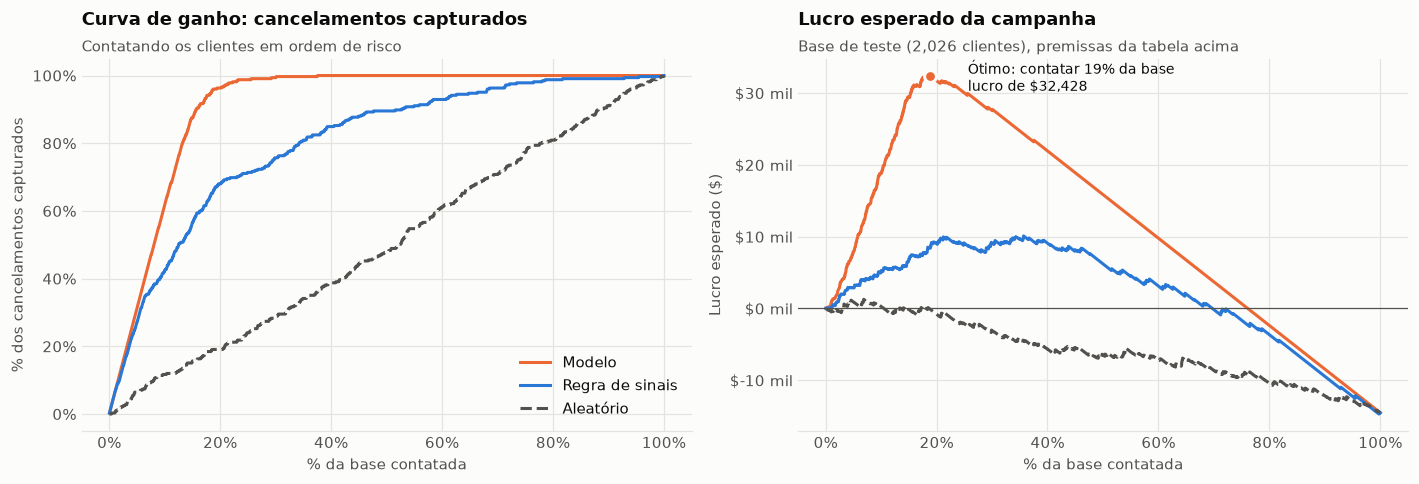

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for curva, nome, cor, estilo in [(curva_modelo, "Modelo", g.LARANJA, "-"),
                                 (curva_regra, "Regra de sinais", g.AZUL, "-"),
                                 (curva_aleatoria, "Aleatório", g.TEXTO_SECUNDARIO, "--")]:
    axes[0].plot(curva["pct_base"], curva["pct_cancelamentos_capturados"], color=cor, linestyle=estilo, label=nome)
    axes[1].plot(curva["pct_base"], curva["lucro"], color=cor, linestyle=estilo, label=nome)

axes[0].set_title("Curva de ganho: cancelamentos capturados")
g.subtitulo(axes[0], "Contatando os clientes em ordem de risco")
axes[0].set(xlabel="% da base contatada", ylabel="% dos cancelamentos capturados")
g.eixo_percentual(axes[0]); g.eixo_percentual(axes[0], "x")
axes[0].legend(loc="lower right")
axes[0].grid(axis="x", visible=True)

axes[1].axhline(0, color=g.TEXTO_SECUNDARIO, linewidth=0.8)
axes[1].scatter([melhor["pct_base"]], [melhor["lucro"]], color=g.LARANJA, s=60, zorder=3,
                edgecolor=g.SUPERFICIE, linewidth=2)
axes[1].annotate(f"Ótimo: contatar {melhor['pct_base']:.0%} da base\nlucro de ${melhor['lucro']:,.0f}",
                 xy=(melhor["pct_base"], melhor["lucro"]), xytext=(25, -10), textcoords="offset points",
                 fontsize=9, color=g.TEXTO)
axes[1].set_title("Lucro esperado da campanha")
g.subtitulo(axes[1], f"Base de teste ({len(y_teste):,} clientes), premissas da tabela acima")
axes[1].set(xlabel="% da base contatada", ylabel="Lucro esperado ($)")
g.eixo_percentual(axes[1], "x")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f} mil"))
axes[1].grid(axis="x", visible=True)
fig.tight_layout()
g.salvar(fig, "08_campanha_retencao")
plt.show()

In [19]:
decis = m.tabela_decis(y_teste, proba_teste)
decis.style.format({"score_medio": "{:.2f}", "taxa_cancelamento": "{:.1%}", "lift": "{:.1f}x",
                    "pct_acumulado_capturado": "{:.0%}"})

,clientes,cancelados,score_medio,taxa_cancelamento,lift,pct_acumulado_capturado
decil,,,,,,
1,203,201,1.00,99.0%,6.2x,62%
2,203,112,0.58,55.2%,3.4x,96%
3,202,10,0.01,5.0%,0.3x,99%
4,203,2,0.00,1.0%,0.1x,100%
5,202,0,0.00,0.0%,0.0x,100%
6,203,0,0.00,0.0%,0.0x,100%
7,202,0,0.00,0.0%,0.0x,100%
8,203,0,0.00,0.0%,0.0x,100%
9,202,0,0.00,0.0%,0.0x,100%


**Leitura:**

- **Quem cancela gera menos receita** (\$190 por ano, contra \$315 de quem fica). Isso acontece porque o uso cai antes da saída: parte da receita já foi perdida quando o cancelamento chega. É mais um argumento para agir cedo.
- **Contatar todos dá prejuízo** (\$14,5 mil negativos): o custo de abordar quem não ia sair supera o que se salva.
- **A regra de sinais** lucra \$10 mil, mas precisa contatar 36% da base.
- **O modelo lucra \$32,4 mil (3,2 vezes a regra)** contatando só 19% da base e alcançando 96% dos cancelamentos.
- **Tabela de decis:** os 10% de maior risco têm 99% de cancelamento (6,2 vezes a média), e os 20% mais arriscados concentram 96% de todos os cancelamentos.

A base de teste é 20% da carteira. Proporcionalmente, o ganho na carteira inteira seria da ordem de **\$160 mil por ciclo de campanha**, sempre sob as premissas acima.

## 7. Recomendações para a diretoria

| # | Ação | Evidência | Como medir |
|---|---|---|---|
| 1 | **Fila mensal de retenção pelo modelo**, contatando os ~20% de maior risco | 96% dos cancelamentos estão nos 2 primeiros decis; lucro 3,2 vezes maior que a regra | Taxa de cancelamento do grupo contatado × grupo de controle |
| 2 | **Alerta automático de queda de uso** (Q4/Q1 abaixo de 0,55 ou menos de 60 transações por ano), com oferta de cashback ou pontos | 60% de cancelamento com Q4/Q1 abaixo de 0,40 | Recuperação do volume transacionado em 90 dias |
| 3 | **Escalonar no 3º contato:** a partir de 3 contatos em 12 meses, o caso vai para uma equipe especializada | Risco passa de 20% no 3º contato e chega a 100% no 6º | Taxa de resolução no primeiro contato; cancelamentos após escalonamento |
| 4 | **Cross-sell como retenção** para clientes com 1 ou 2 produtos | 26% a 28% de cancelamento, contra 11% a 12% com 4 ou mais produtos | Produtos por cliente; cancelamento por coorte |
| 5 | **Não segmentar retenção por perfil demográfico** | Tamanho de efeito abaixo de 0,04 para sexo, renda, escolaridade e estado civil | - |

**Pronto para a operação:** o script `python -m src.pontuar` gera `reports/fila_retencao.csv` com os clientes ativos ordenados por risco, a faixa de risco, os sinais que acenderam e a receita em jogo. É a lista que a equipe de retenção usaria na segunda-feira de manhã.

**Antes de escalar:** rodar a ação 1 como **teste A/B** (metade da fila recebe a ação, metade não) para medir a taxa real de sucesso e substituir a premissa de 25%.

## 8. Limitações e próximos passos

- **Foto de um momento, não série temporal:** a base não informa *quando* cada cliente cancelou. Parte das variáveis de uso (como a queda Q4/Q1) pode refletir o próprio processo de saída. Em produção, o modelo deve ser treinado com variáveis medidas **antes** de uma data de corte, prevendo cancelamentos nos meses **seguintes**.
- **Receita estimada:** o valor financeiro depende de premissas. O próximo passo é substituí-las pela margem real por cliente e pela taxa de sucesso medida em um **teste A/B** da campanha.
- **Uplift:** o modelo diz *quem vai sair*, não *quem vai ficar se for contatado*. Com dados de campanhas anteriores, um modelo de *uplift* direcionaria a verba só para quem responde à ação.
- **Monitoramento:** acompanhar mensalmente o drift das variáveis principais e a calibração das probabilidades.